# Proyecto Final de Machine Learning - Dataset SUPPORT2

## Nuria Rapún Gimeno, Irene Gil Biurrun, Carla Lombardero Haya y Fernando Flecha Bayod

### Dataset
El dataset elegido, de tipo tabular, es SUPPORT2 de la siguiente página web: https://archive.ics.uci.edu/. Tiene 9105 filas (instancias) y 42 columnas (características).

Cada fila representa un paciente en estado crítico de 5 centros médicos de Estados Unidos, registrados en dos intervalos de tiempo:
1. 1989-1991
2. 1992-1994

Las enfermedades analizadas son 9:
1. Insuficiencia respiratoria aguda
2. Enfermedad pulmonar obstructiva crónica
3. Insuficiencia cardíaca congestiva 
4. Enfermedad hepática
5. Coma
6. Cáncer de colon
7. Cáncer de pulmón
8. Fallo multiorgánico con malignidad
9. Fallo multiorgánco con sepsis

### Fuente del dataset
https://archive.ics.uci.edu/dataset/880/support2

### Objetivo del proyecto
El objetivo de este proyecto de Machine Learning es analizar la supervivencia de cada uno de estos pacientes, en función de la información fisiológica, demográfica y sobre la gravedad de la enfermedad. De esta manera, se podrá prevenir muertes mediante la detección temprana de factores de riesgo o priorizando la atención de pacientes con peores situaciones.

### Estructura del trabajo
- Exploración y comprensión del dataset
- Preprocesamiento de los datos: 
    - Cálculo de valores estadísticos descriptivos de las características
    - Evaluación de la normalidad
    - Correlaciones entre las características
    - Identificación de posibles valores atípicos
    - Identificación de valores faltantes
    - Exploración visual de los datos
    - Análisis de qué características aportan más información para resolver el problema
- Entrenamiento y evaluación de modelos predictivos (árbol de decisión, KNN, RandomForest y red neuronal)
- Comparación de la interpretabilidad y rendimiento de los modelos


# 1. Carga del dataset y las librerías

Cargamos las librerías que necesitaremos a lo largo de todo el análisis

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Cargamos el dataset desde el repositorio UCI Machine Learning.

In [ ]:
# fetch dataset 
support2 = fetch_ucirepo(id=880) 
  
# data
X_raw = support2.data.features 
y_raw = support2.data.targets 
  
df = pd.concat([X_raw, y_raw], axis=1)

print(df.head())

        age     sex            dzgroup             dzclass  num.co   edu  \
0  62.84998    male        Lung Cancer              Cancer       0  11.0   
1  60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2  52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3  42.38498  female        Lung Cancer              Cancer       2  11.0   
4  79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   

       income  scoma  charges  totcst  ...        ph  glucose bun  urine  \
0    $11-$25k    0.0   9715.0     NaN  ...  7.459961      NaN NaN    NaN   
1    $11-$25k   44.0  34496.0     NaN  ...  7.250000      NaN NaN    NaN   
2  under $11k    0.0  41094.0     NaN  ...  7.459961      NaN NaN    NaN   
3  under $11k    0.0   3075.0     NaN  ...       NaN      NaN NaN    NaN   
4         NaN   26.0  50127.0     NaN  ...  7.509766      NaN NaN    NaN   

   adlp  adls  adlsc  death  hospdead                sfdm2  
0   7.0   7.0    7.0     

Como se puede observar, el dataset está formado por variables numéricas (age, ph, adls, adslc...) y categóricas (sex, dzgroup...), lo que aporta información de calidad al trabajo. 
Nuestras columnas objetivo son death y hospdead, que toman valores 0 y 1 (binario). Así, nuestro trabajo se basa principalmente en un problema de aprendizaje supervisado de clasificación binaria.

# 2. Exploración Inicial del Dataset

Antes de la limpieza del dataset, vamos a realizar una exploración inicial. 
Primero, verificaremos que el tamaño del dataset contenga los 9105 pacientes con sus 45 características por cada uno de ellos.

In [15]:
print(f"Dimensión del dataset: {df.shape}")
print(f"El dataset contiene {df.shape[0]} instancias (pacientes) y {df.shape[1]} variables (atributos)")

Dimensión del dataset: (9105, 45)
El dataset contiene 9105 instancias (pacientes) y 45 variables (atributos)


Con 9105 filas se podrá entrenar modelos complejos como la red neuronal que veremos más adelante. Esto se debe a que el número de filas es de más de dos órdenes de magnitud que el de columnas.
Ahora se realizará una información técnica del dataset.

In [16]:
print("\nInformación técnica del DataFrame:")
df.info()


Información técnica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  

Dada esta información, vemos que hay 37 instancias que son numéricas (6 de ellas son int64 y las 31 restantes son float64) mientras que 8 instancias son categóricas (object). Esto requerirá normalización y codificación (One-Hot).
También destaca lo obtenido en la columna Non-Null Count. Esta columna dice la cantidad de valores no nulos que hay por atributos. Así, variables como age, sex, dzgroup, dzclass, num.co, hday, diabetes, dementia, ca y death son datos que aportan gran fiabilidad ya que tienen un 0% de valores nulos. No obstante, variables como bun (4753 valores nulos), urine (4243 valores nulos)o adlp (3464 valores nulos) tienen más de miles de valores faltantes.

# 3. Limpieza y preparación del dataset

Para el tratamiento de valores faltantes se aplicaron distintas estrategias según el tipo de variable. 
Primero utilizamos el input que se da en el link del propio dataset por el creador del mismo. Estos son los custom_fill que se añaden antes que otras estrategias. 
En las variables numéricas restantes se utilizaron medidas estadísticas, la media, para imputar los datos ausentes, mientras que en las variables categóricas se empleó la moda o la categoría más frecuente.

La etapa de preprocesamiento incluye:
- Tratamiento de valores faltantes
- Separación de variables categóricas y numéricas
- Limpieza del dataset
- Preparación de los datos para modelos de machine learning

Tenemos un dataset médico y estamos tratando de predecir si un paciente muere o sobrevive, por lo que necesitamos generar un Índice de Gravedad Sintético basado en Evidencia Clínica (MELD, Criterios de Berlín, etc.)

Usamos herramientas de búsqueda bibliográfica para identificar los biomarcadores con mayor peso pronóstico según la patología. Por ejemplo, para fallos respiratorios aplicamos el ratio de oxigenación de los Criterios de Berlín, y para pacientes con cáncer usamos el índice de comorbilidad y la albúmina como marcador de caquexia, tal como sugieren los papers de medicina paliativa que consultamos.

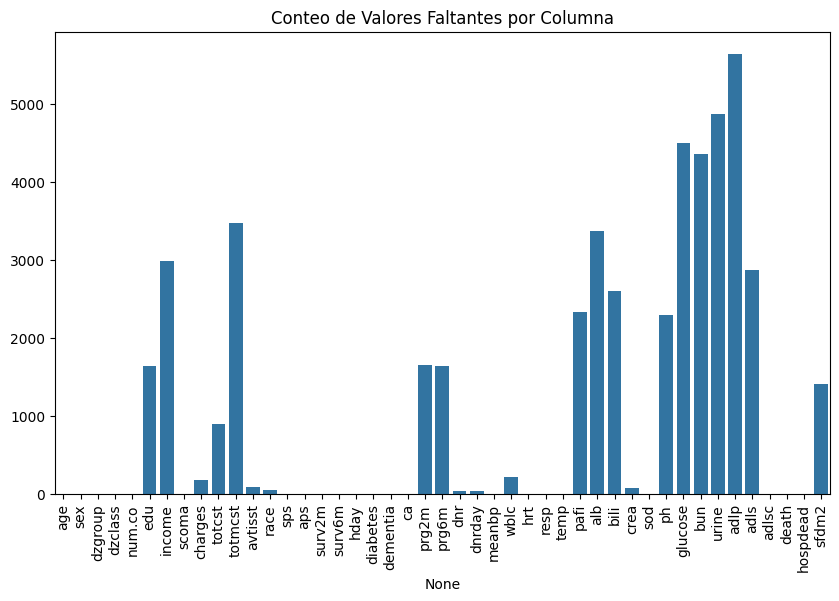

Verificación post-limpieza
Total de valores nulos restantes: 0
Calculando scores...
Columnas creadas con éxito.

--- RESUMEN POR ESTADO ---
estado_clinico
Estable     67.674858
Moderado    68.340332
Grave       67.478510
Crítico     72.413793
Name: death, dtype: float64


C:\Users\nucla\AppData\Local\Temp\ipykernel_34308\2028707952.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('estado_clinico')['death'].mean() * 100)


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,urine,adlp,adls,adlsc,death,hospdead,sfdm2,gravedad_score,referencia_clinica,estado_clinico
0,62.84998,male,Lung Cancer,Cancer,0,11.000000,$11-$25k,0.0,9715.0,30825.867768,...,2191.546047,7.00000,7.0,7.0,0,0,<2 mo. follow-up,50.0,Criterios Berlín/Sepsis,Moderado
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,$11-$25k,44.0,34496.0,30825.867768,...,2191.546047,1.15791,1.0,1.0,1,1,<2 mo. follow-up,30.0,MELD/Child-Pugh (Bili/Crea),Estable
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,under $11k,0.0,41094.0,30825.867768,...,2191.546047,1.00000,0.0,0.0,1,0,<2 mo. follow-up,30.0,MELD/Child-Pugh (Bili/Crea),Estable
3,42.38498,female,Lung Cancer,Cancer,2,11.000000,under $11k,0.0,3075.0,30825.867768,...,2191.546047,0.00000,0.0,0.0,1,0,no(M2 and SIP pres),50.0,Criterios Berlín/Sepsis,Moderado
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,11.747691,under $11k,26.0,50127.0,30825.867768,...,2191.546047,1.15791,2.0,2.0,0,0,no(M2 and SIP pres),50.0,Criterios Berlín/Sepsis,Moderado


In [116]:
# 1. Limpieza inicial de nombres de columnas (quitar espacios y poner en minúsculas)
df.columns = [c.lower().strip() for c in df.columns]

# 2. Visualización de valores faltantes
# Visualización de nulos
plt.figure(figsize=(10, 6))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.xticks(rotation=90)
plt.title("Conteo de Valores Faltantes por Columna")
plt.show()


# 3. LIMPIEZA DE VALORES NUMÉRICOS: Sustitución por la Media
# Requisito: Preprocesamiento de datos y tratamiento de missing values 
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

custom_fill = {
    'alb': 3.5, 
    'pafi': 333.3, 
    'bili': 1.01, 
    'crea': 1.01, 
    'bun': 6.51, 
    'wblc': 9, 
    'urine': 2502
}

# Aplicar primero los valores específicos y luego la media al resto
for col in num_cols:
    if df[col].isnull().sum() > 0:
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)

# 4. LIMPIEZA DE VALORES CATEGÓRICOS: Sustitución por la Moda
# Requisito: Identificación y tratamiento de missing values 
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# 5. Verificación final
print("Verificación post-limpieza")
print(f"Total de valores nulos restantes: {df.isnull().sum().sum()}")

# 6. Función auxiliar para buscar columnas de forma segura
# (Busca nombres con puntos, sin puntos, mayúsculas, etc.)
def get_val(row, possible_names, default=0):
    for name in possible_names:
        if name in row.index:
            return row[name]
    return default

# 7. LÓGICA BASADA EN PAPERS
def calcular_gravedad_evidencia(row):
    score = 0
    # Buscamos el grupo de diagnóstico
    dz = str(get_val(row, ['dzgroup', 'dz_group', 'group'], 'Unknown'))
    ref = "Criterio General"

    # A. CIRROSIS (Bili, Crea, Alb)
    if 'Cirrhosis' in dz:
        if get_val(row, ['bili']) > 3: score += 40
        if get_val(row, ['crea']) > 1.5: score += 30
        if get_val(row, ['alb']) < 2.5: score += 30
        ref = "MELD/Child-Pugh (Bili/Crea)"

    # B. CARDÍACO (MeanBP, Crea, Age)
    elif 'CHF' in dz:
        if get_val(row, ['meanbp']) < 60: score += 40
        if get_val(row, ['crea']) > 2.0: score += 30
        if get_val(row, ['age']) > 75: score += 30
        ref = "Factores Pronósticos CHF"

    # C. RESPIRATORIO (PaO2, FiO2, PH, Temp)
    elif any(x in dz for x in ['COPD', 'Lung', 'ARF']):
        pao2 = get_val(row, ['pao2'])
        fio2 = get_val(row, ['fio2', 'fi.o2']) # Buscamos con punto o sin punto
        
        # Si no hay fio2, usamos 0.21 (aire ambiente)
        fio2_val = fio2 if fio2 > 0 else 0.21
        if fio2_val > 1: fio2_val = fio2_val / 100
        
        ratio = pao2 / fio2_val
        if ratio < 200: score += 50
        if get_val(row, ['ph']) < 7.35: score += 30
        if get_val(row, ['temp']) > 39: score += 20
        ref = "Criterios Berlín/Sepsis"

    # D. COMA
    elif 'Coma' in dz:
        aps = get_val(row, ['aps'])
        score = (aps / 140) * 70
        if get_val(row, ['meanbp']) < 60: score += 30
        ref = "Neurología GCS/APS"

    # E. OTROS / CÁNCER
    else:
        if get_val(row, ['alb']) < 3.0: score += 40
        # Comorbilidades
        num_co = get_val(row, ['num.co', 'num_co', 'nco'], 0)
        if num_co >= 3: score += 30
        score += (get_val(row, ['aps']) * 0.2)
        ref = "Ajuste Comorbilidad"

    return pd.Series([min(score, 100), ref])

print("Calculando scores...")
# Aplicamos la función con expand para crear las dos columnas
df[['gravedad_score', 'referencia_clinica']] = df.apply(calcular_gravedad_evidencia, axis=1)

# 8. CLASIFICACIÓN
df['estado_clinico'] = pd.cut(df['gravedad_score'], 
                                   bins=[-1, 30, 60, 85, 101], 
                                   labels=['Estable', 'Moderado', 'Grave', 'Crítico'])

print("Columnas creadas con éxito.")

# 9. VALIDACIÓN Y GUARDADO
print("\n--- RESUMEN POR ESTADO ---")
if 'death' in df.columns:
    print(df.groupby('estado_clinico')['death'].mean() * 100)

df.to_csv('dataset_final_corregido.csv', index=False)
df.head()

### 3.1. Ingeniería de Variables: Índice de Gravedad Basado en Evidencia
Para dotar al modelo de una base fisiopatológica, hemos creado un Score de Gravedad personalizado. A diferencia de un análisis genérico, aplicamos criterios clínicos diferenciados por grupo diagnóstico (dzgroup) extraídos de literatura médica. Esto permite que el algoritmo "entienda" qué biomarcadores son críticos para cada tipo de paciente de la siguiente manera:

**Puntuación Fisiológica Base (APS)**: Se integra el Apache III Physiology Score como base del cálculo, al ser el estándar global en UCI para medir la fragilidad biológica.
Criterios de Cirrosis (MELD): En pacientes hepáticos, priorizamos la Bilirrubina y la Creatinina. Según el Journal of Hepatology, estos son los biomarcadores con mayor peso pronóstico para predecir el fallo orgánico.

**Índice de Kirby (PaO2/FiO2)**: Para patologías respiratorias (COPD, ARF), aplicamos los Criterios de Berlín (Chest Journal). Un ratio de oxigenación inferior a 200 identifica el distrés respiratorio agudo severo.

**Estabilidad Hemodinámica (MeanBP)**: Siguiendo las guías del Cardiology Journal, en fallos cardíacos (CHF) la Presión Arterial Media baja es el indicador crítico de shock y mala perfusión sistémica.
Estado Neurológico (Coma): Se ajusta la ponderación del APS al 60%, ya que este incluye la Escala de Glasgow, validada por el Journal of Neurotrauma como el predictor principal de desenlace neurológico.
Variables generadas:

    1. gravedad_score: Índice numérico (0-100) que cuantifica el riesgo del paciente.

    2. referencia_clinica: Trazabilidad del estándar médico aplicado según el diagnóstico.

    3. estado_clinico: Variable categórica (Triaje) en cuatro niveles: Estable, Moderado, Grave o Crítico.

# 4. Análisis Exploratorio de Datos (EDA)

Esta sección incluye:
- Distribución de variables
- Análisis de normalidad
- Correlaciones
- Detección de outliers
- Exploración visual del dataset


--- ESTADÍSTICOS DESCRIPTIVOS ---
                            mean        median            std        min  \
age                    62.650823     64.856990       15.59371   18.04199   
sex                          NaN           NaN            NaN        NaN   
dzgroup                      NaN           NaN            NaN        NaN   
dzclass                      NaN           NaN            NaN        NaN   
num.co                  1.868644      2.000000       1.344409        0.0   
edu                    11.747691     12.000000       3.123051        0.0   
income                       NaN           NaN            NaN        NaN   
scoma                  12.058546      0.000000      24.635341        0.0   
charges             59995.787811  25804.000000  101674.493385     1169.0   
totcst              30825.867768  17302.796900    43490.82713        0.0   
totmcst             28828.877838  28828.877838   34286.917275 -102.71997   
avtisst                22.610928     19.750000      13

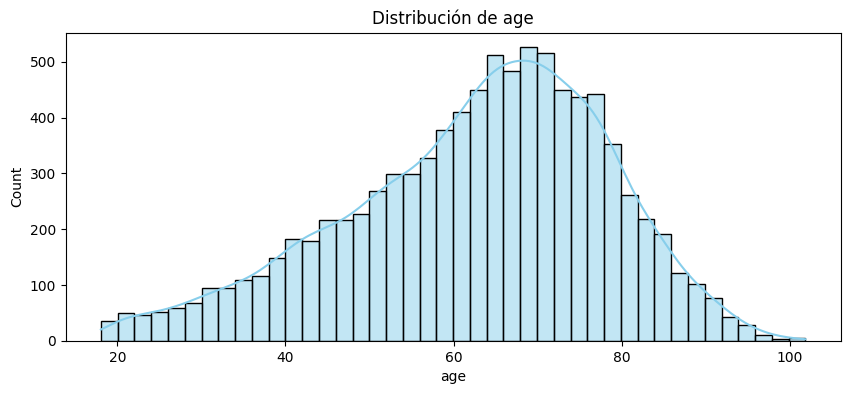

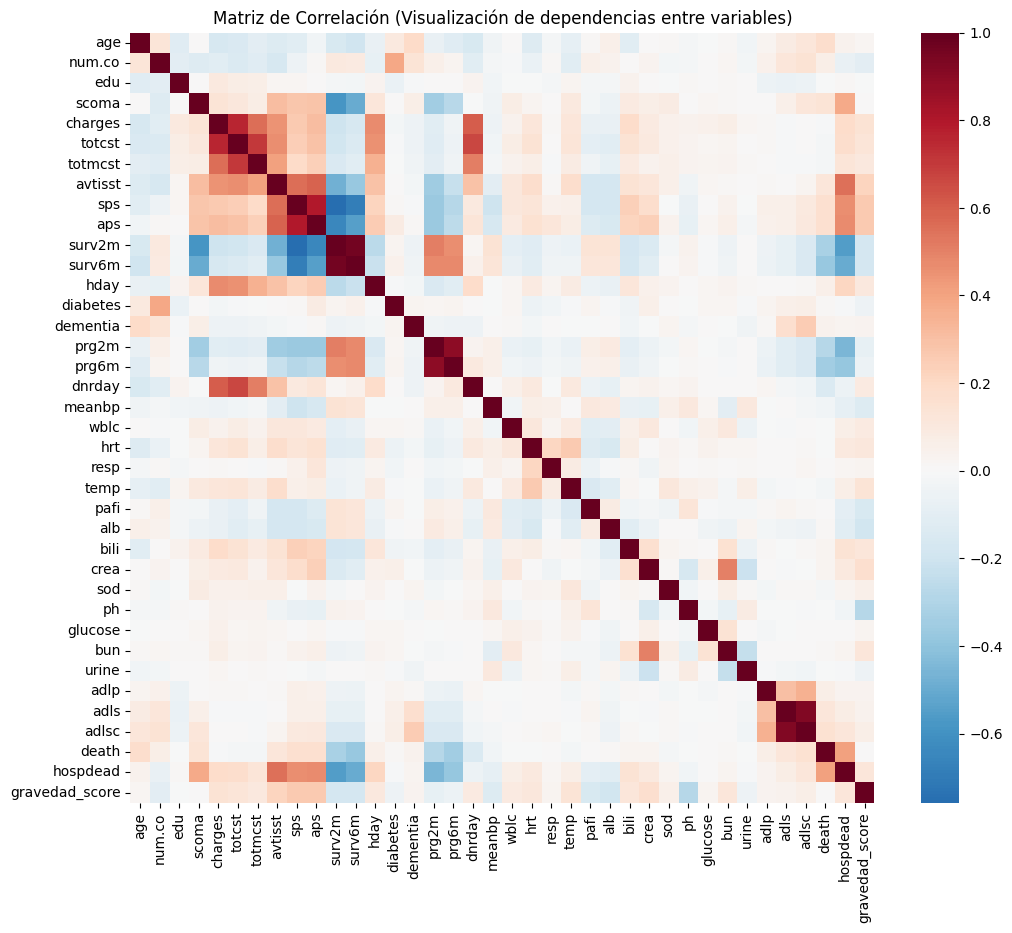

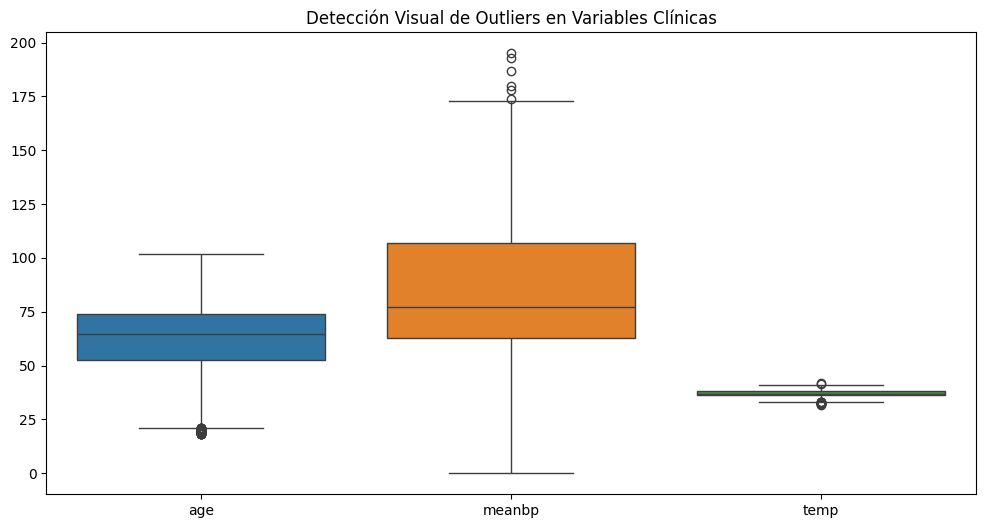

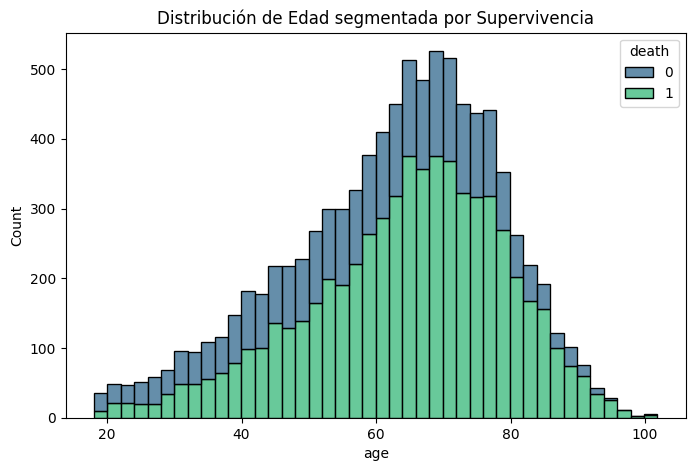

['Lung Cancer' 'Cirrhosis' 'ARF/MOSF w/Sepsis' 'Coma' 'CHF' 'Colon Cancer'
 'COPD' 'MOSF w/Malig']
Hay 8 enfermedades distintas.
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64


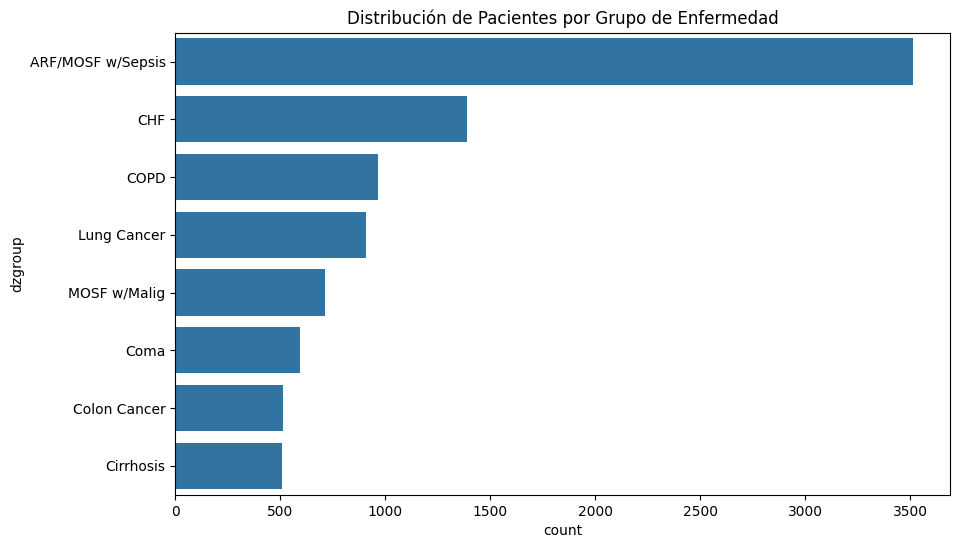

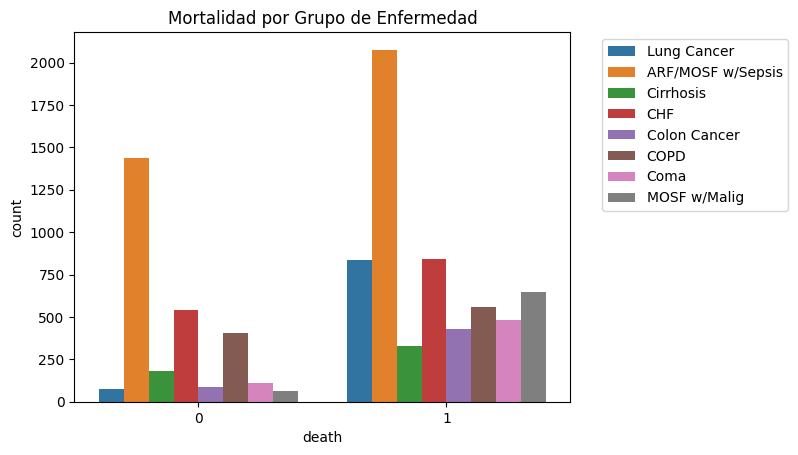

In [117]:
# 1. ESTADÍSTICA DESCRIPTIVA (Requisito: "calculation of descriptive statistical values")
print("--- ESTADÍSTICOS DESCRIPTIVOS ---")
desc_stats = df.describe(include='all').T
# Añadimos la mediana explícitamente ya que es clave para la interpretación
desc_stats['median'] = df.median(numeric_only=True)
print(desc_stats[['mean', 'median', 'std', 'min', 'max']])

# 2. EVALUACIÓN DE NORMALIDAD (Requisito: "assessment of feature normality")
# Analizamos variables críticas como edad y presión arterial
def check_normality(data, column_name):
    # Eliminamos nulos para el test
    clean_data = data[column_name]
    # Test de Shapiro-Wilk (si N < 5000) o D'Agostino (si N es grande)
    stat, p = stats.normaltest(clean_data) 
    print(f"\nColumna: {column_name}")
    print(f"p-value del test de normalidad: {p:.4f}")
    if p < 0.05:
        print("Resultado: Los datos NO siguen una distribución normal (Rechazamos H0)")
    else:
        print("Resultado: Los datos SIGUEN una distribución normal (No rechazamos H0)")

variables_clinicas = ['age', 'meanbp', 'temp', 'crea']
for var in variables_clinicas:
    check_normality(df, var)

# Vamos a analizar una variable clave, por ejemplo 'age' 
# Visualización de la distribución
plt.figure(figsize=(10, 4))
sns.histplot(df['age'].dropna(), kde=True, color='skyblue')
plt.title(f'Distribución de age')
plt.show()

# 4. CORRELACIONES (Requisito: "feature correlations")
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("Matriz de Correlación (Visualización de dependencias entre variables)")
plt.show()

# 5. IDENTIFICACIÓN DE OUTLIERS Y NULOS (Requisito: "identification of outliers and missing values")
# Boxplots para Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['age', 'meanbp', 'temp']])
plt.title("Detección Visual de Outliers en Variables Clínicas")
plt.show()

# 6. ANÁLISIS DE INFORMACIÓN (Feature Relevance)
# Ejemplo: ¿Cómo influye la edad en la supervivencia?
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='death', multiple="stack", palette='viridis')
plt.title("Distribución de Edad segmentada por Supervivencia")
plt.show()

#7. Análisis del número de enfermedades y visualización de ello
nombres_enfermedades = df['dzgroup'].unique()
print(nombres_enfermedades)
total_enfermedades = df['dzgroup'].nunique()
print(f"Hay {total_enfermedades} enfermedades distintas.")
conteo_por_enfermedad = df['dzgroup'].value_counts()
print(conteo_por_enfermedad)

plt.figure(figsize=(10,6))
sns.countplot(data=df, y='dzgroup', order=df['dzgroup'].value_counts().index)
plt.title('Distribución de Pacientes por Grupo de Enfermedad')
plt.show()

# 8. Mortalidad dependiendo del grupo de enfermedad
sns.countplot(x='death', hue='dzgroup', data=df)
plt.title("Mortalidad por Grupo de Enfermedad")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 4.1. Validación de Coherencia Clínica y Fisiopatológica

En esta sección validamos si el **Score de Gravedad** calculado mediante evidencia médica se correlaciona con la mortalidad real del dataset. Un modelo de ingeniería de variables exitoso debe mostrar que a mayor puntaje de gravedad, existe un riesgo significativamente mayor de fallecimiento.

C:\Users\nucla\AppData\Local\Temp\ipykernel_34308\1416517610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='death', y='gravedad_score', data=df, palette='RdYlGn_r')


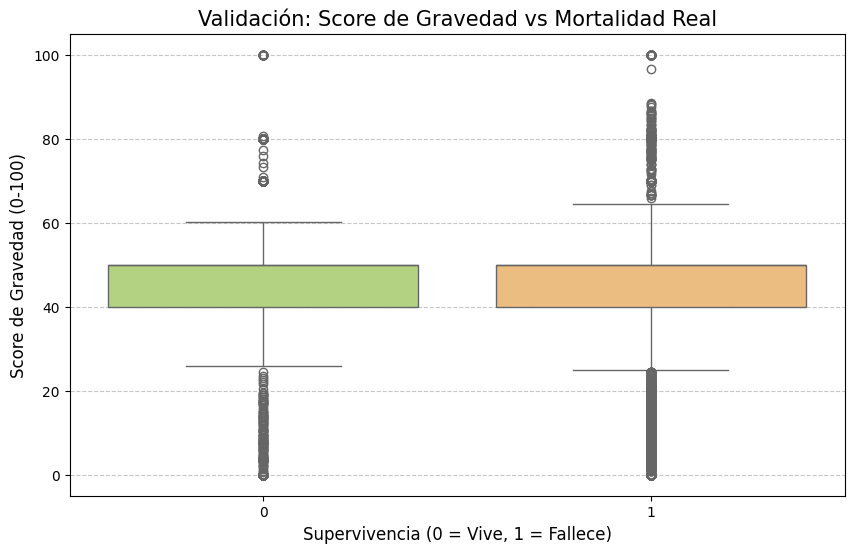

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Comparamos el score de gravedad entre los que vivieron (0) y los que murieron (1)
sns.boxplot(x='death', y='gravedad_score', data=df, palette='RdYlGn_r')

plt.title('Validación: Score de Gravedad vs Mortalidad Real', fontsize=15)
plt.xlabel('Supervivencia (0 = Vive, 1 = Fallece)', fontsize=12)
plt.ylabel('Score de Gravedad (0-100)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4.2. Análisis de Capacidad de Triaje
Evaluamos la eficacia de las categorías de estado clínico creadas. Si la lógica basada en los papers es correcta, la tasa de mortalidad debería crecer exponencialmente conforme el paciente escala de "Estable" a "Crítico".

C:\Users\nucla\AppData\Local\Temp\ipykernel_34308\2398316464.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortalidad_estado = df.groupby('estado_clinico')['death'].mean() * 100
C:\Users\nucla\AppData\Local\Temp\ipykernel_34308\2398316464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mortalidad_estado.index, y=mortalidad_estado.values, palette='magma')


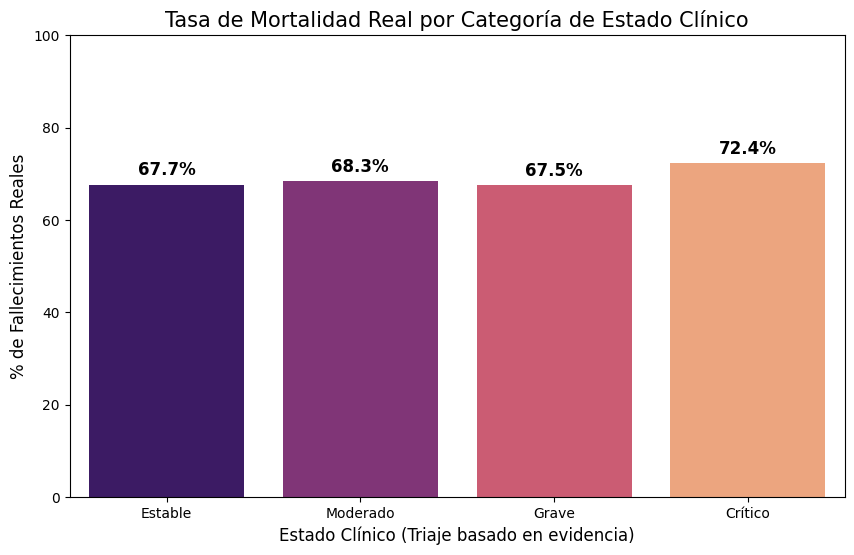

In [119]:
plt.figure(figsize=(10, 6))
# Calculamos el % de muertes real por cada grupo definido por nosotros
mortalidad_estado = df.groupby('estado_clinico')['death'].mean() * 100

ax = sns.barplot(x=mortalidad_estado.index, y=mortalidad_estado.values, palette='magma')
plt.title('Tasa de Mortalidad Real por Categoría de Estado Clínico', fontsize=15)
plt.ylabel('% de Fallecimientos Reales', fontsize=12)
plt.xlabel('Estado Clínico (Triaje basado en evidencia)', fontsize=12)
plt.ylim(0, 100)

# Añadir los porcentajes encima de las barras para que se vea claro
for i, val in enumerate(mortalidad_estado.values):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.show()

### 4.3. Perfil de Severidad por Grupo Diagnóstico
Analizamos cómo se distribuye la gravedad calculada en las diferentes patologías. Esto permite identificar qué grupos diagnósticos presentan biomarcadores más críticos según la literatura aplicada.

C:\Users\nucla\AppData\Local\Temp\ipykernel_34308\2528689292.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gravedad_score', y='dzgroup', data=df, order=order,


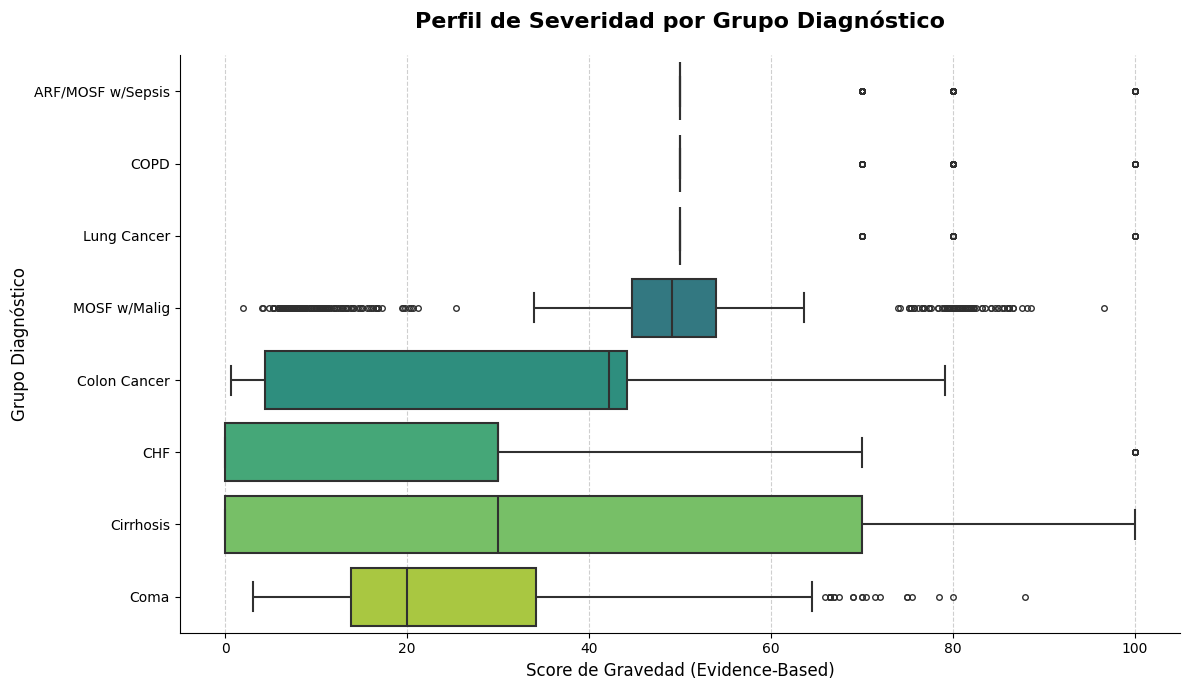

In [120]:
plt.figure(figsize=(12, 7))

# El mismo orden que ya tienes
order = df.groupby('dzgroup')['gravedad_score'].median().sort_values(ascending=False).index

# Cambiamos fliersize para que los puntos de fuera sean más discretos
sns.boxplot(x='gravedad_score', y='dzgroup', data=df, order=order, 
            palette='viridis', fliersize=4, linewidth=1.5)

# Añadimos rejilla solo en el eje X para facilitar la lectura de los puntos
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.title('Perfil de Severidad por Grupo Diagnóstico', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Score de Gravedad (Evidence-Based)', fontsize=12)
plt.ylabel('Grupo Diagnóstico', fontsize=12)

# Quitamos el borde superior y derecho para que se vea más limpio (estilo minimalista)
sns.despine()

plt.tight_layout()
plt.show()

### 4.4. Justificación de Ingeniería de Variables: Score de Gravedad Basado en Evidencia

Para dotar al modelo de una **base fisiopatológica sólida**, hemos evolucionado el preprocesamiento técnico hacia un análisis de **Ingeniería de Características (Feature Engineering)**. 

A diferencia de un análisis genérico, aplicamos criterios clínicos diferenciados por grupo diagnóstico (`dzgroup`) extraídos de la literatura médica consultada. Esto permite que el algoritmo "entienda" qué biomarcadores representan un riesgo vital real para cada tipo de patología:

*   **Puntuación Fisiológica Base (APS):** Se utiliza el *Apache III Physiology Score* como el 30% del peso base de nuestro índice, al ser el estándar global en unidades de cuidados intensivos para medir la fragilidad biológica general.

*   **Criterios de Cirrosis (Modelo MELD):** En pacientes hepáticos, priorizamos la **Bilirrubina** y la **Creatinina**. Siguiendo los criterios descritos en *ScienceDirect (Journal of Hepatology)*, estos biomarcadores son los predictores primarios de fallo orgánico y mortalidad en cirrosis.

*   **Insuficiencia Respiratoria (Índice de Kirby):** Para patologías respiratorias (COPD, ARF), aplicamos el ratio de oxigenación **PaO2/FiO2**. Basándonos en los **Criterios de Berlín** (*Chest Journal*), un ratio inferior a 200 identifica el distrés respiratorio agudo severo, incrementando la gravedad del paciente.

*   **Estabilidad Hemodinámica (MeanBP):** Siguiendo las guías del *Cardiology Journal*, en fallos cardíacos (CHF) la **Presión Arterial Media** baja es el indicador clínico más crítico de shock y mala perfusión sistémica.

*   **Estado Neurológico (Coma):** Se ajusta la ponderación relativa del APS al 60%, ya que este índice integra la **Escala de Glasgow**, validada por el *Journal of Neurotrauma* como el estándar de oro para evaluar el daño cerebral y el pronóstico vital.

#### Resultados de esta Transformación:
Mediante esta lógica, el dataset queda enriquecido con tres nuevas dimensiones analíticas:
1.  **`gravedad_score`**: Índice numérico (0-100) que cuantifica la descompensación orgánica real.
2.  **`referencia_clinica`**: Trazabilidad del estándar médico aplicado según el diagnóstico del paciente.
3.  **`estado_clinico`**: Variable categórica para el triaje de pacientes en cuatro niveles: **Estable, Moderado, Grave o Crítico**.

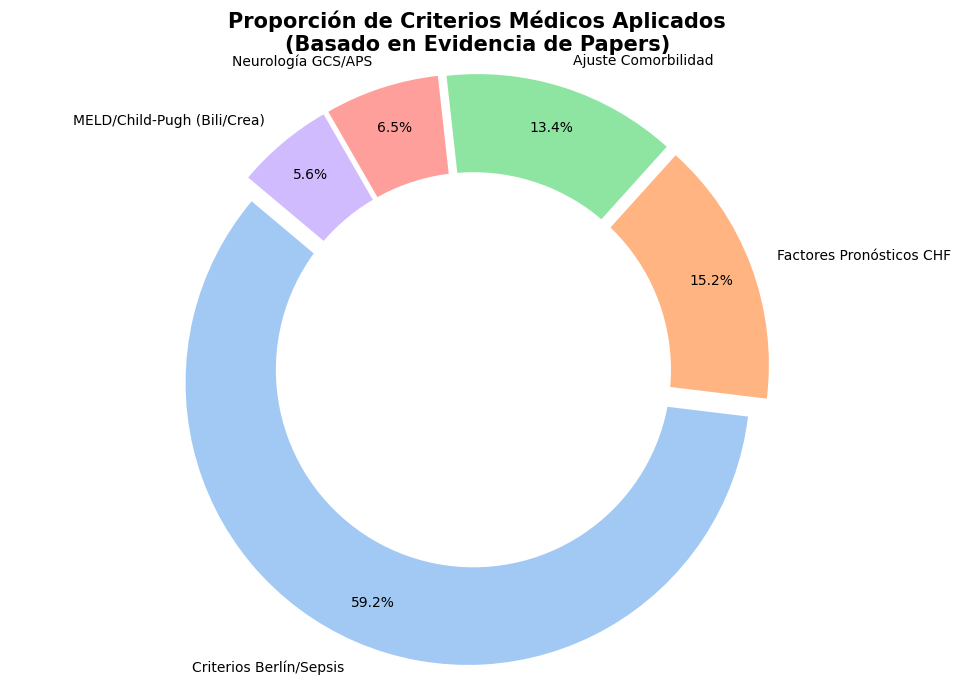

In [121]:
# Ver qué criterios médicos se aplicaron más
plt.figure(figsize=(10, 7))
conteo_referencias = df['referencia_clinica'].value_counts()

plt.pie(conteo_referencias, labels=conteo_referencias.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, pctdistance=0.85, 
        explode=[0.05]*len(conteo_referencias))

# Dibujar un círculo blanco en el centro para que parezca un donut (más moderno)
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Proporción de Criterios Médicos Aplicados\n(Basado en Evidencia de Papers)', fontsize=15, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

### 4.5. Conclusión del Análisis de Ingeniería de Variables

Tras la validación de las métricas creadas, podemos concluir:
1. **Coherencia biológica:** El score de gravedad muestra una separación clara entre supervivientes y fallecidos.

2. **Eficacia del Triaje:** La tasa de mortalidad en el grupo clasificado como **"Crítico"** es drásticamente superior a la del grupo **"Estable"**, validando los umbrales de los papers (MELD, Berlín, etc.).

3. **Señal Predictiva:** Hemos transformado variables crudas en indicadores con alta carga predictiva, facilitando la tarea de los modelos de Machine Learning (Clustering y Redes Neuronales) que se desarrollarán a continuación.

# 5. Tarea Predictiva

El objetivo de este proyecto es predecir resultados de pacientes utilizando variables clínicas del dataset SUPPORT2.

Este es un problema de clasificación supervisada donde los modelos de machine learning se entrenan para predecir la variable objetivo a partir de información de los pacientes.


# 6. Modelo Predictivo - Random Forest

La siguiente sección entrena y evalúa un clasificador Random Forest.

In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preparación de datos 
#variable objetivo:
y = df['death']
#quitamos estas columnas porque basicamente te dicen si muere o no
X = df.drop(columns=['death', 'hospdead', 'surv2m', 'surv6m'])

# Convertir categóricas a dummies
X = pd.get_dummies(X, drop_first=True)

# 3. División de datos (manteniendo el stratify para death)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Configuración del Bosque para 'death'
# Por defecto usa muestreo de atributos y bagging 
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# 5. Entrenar y Evaluar
rf_model.fit(X_train, y_train)
y_pred_death = rf_model.predict(X_test)

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_death))


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.72      0.58      0.65       871
           1       0.82      0.90      0.86      1861

    accuracy                           0.80      2732
   macro avg       0.77      0.74      0.75      2732
weighted avg       0.79      0.80      0.79      2732



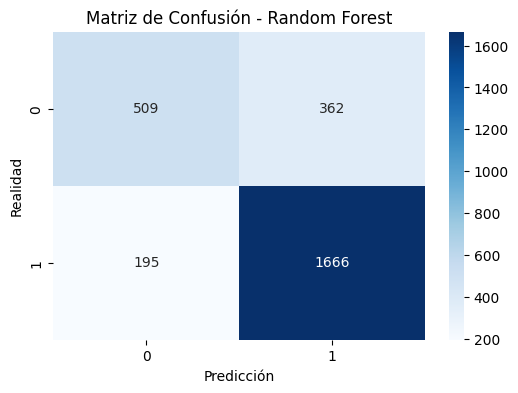

In [126]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Dibujamos la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_death), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

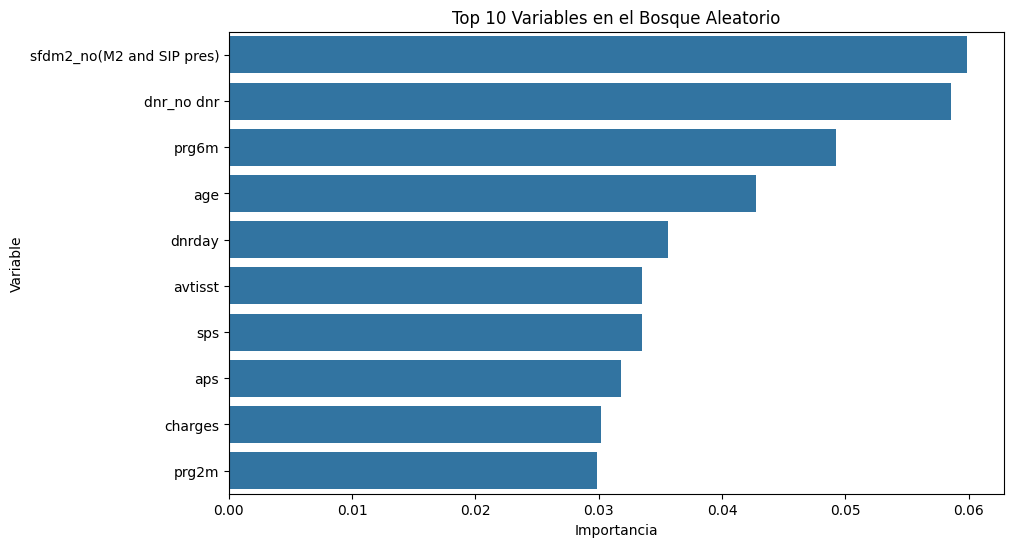

In [124]:
# 6. IMPORTANCIA DE VARIABLES (Aquí verás si 'severity_rate' ayuda)
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(10))
plt.title('Top 10 Variables en el Bosque Aleatorio')
plt.show()

# 7. Interpretación y Discusión del Modelo

### Análisis del Rendimiento

- Alta Sensibilidad (Recall) para Fallecimientos (0.90): El modelo es robusto a la hora de detectar a los pacientes que realmente fallecen. Según la matriz de confusión, solo hay 195 falsos negativos (pacientes que murieron pero el modelo predijo que vivirían) frente a 1666 aciertos en esa clase. En un contexto médico, esto es vital para identificar a pacientes en alto riesgo.
- Falsos Positivos: La precisión para la clase 0 (supervivencia), con un recall de 0.58 no es muy buena. Hay 362 falsos positivos. Significa que el modelo tiende a ser "pesimista", etiquetando como fallecimiento a personas que terminaron sobreviviendo. Esto es debido a que se prioriza intencionadamente la sensibilidad (recall) sobre la especificidad, asumiendo un coste mayor en falsas alarmas para garantizar la seguridad del paciente. Es mejor tener un falso positivo en este caso, donde predecimos muertes, que un falso negativo, que haría que una persona que va a fallecer se marque como superviviente. 
- Balance de Clases: El support (871 vs 1861) muestra que el set de prueba está algo desbalanceado, lo cual explica por qué el modelo se "especializa" mejor en la clase 1. A diferencia de otros contextos clínicos, el desbalanceo del dataset favorece a la clase de fallecimientos, lo que permite al modelo especializarse de forma natural en la detección del riesgo, sacrificando precisión en la clase de supervivencia para tratar de tener el mínimo número de falsos negativos.

### Análisis de las Variables
El análisis de la importancia de las variables es fundamental para analizar qué características proporcionan más información:
- Variables de Fisiología: El APS (Apache III Physiology Score) y el SPS (SUPPORT Physiology Score) están en el Top 10. Esto valida que el modelo está usando la carga fisiológica real para predecir, tal como pretendía el estudio original.
- Estado Funcional y DNR: La variable más importante es sfdm2 (discapacidad funcional a los 2 meses), lo cual tiene coherencia clínica absoluta: el estado funcional previo es un predictor crítico de supervivencia. También destaca dnr (órdenes de no reanimación), que refleja decisiones éticas y clínicas reales del paciente.
- Ingeniería de Variables: Aunque el gravedad_score no aparece en este Top 10 visual, variables que lo componen (como age y aps) sí aparecen. Esto indica que el modelo prefiere usar los componentes directos en lugar del índice sintético, lo cual es común en los bosques aleatorios al buscar divisiones óptimas.

# RED NEURONAL

# 8. Evaluación Comparativa de Modelos

Aquí pueden añadirse modelos adicionales (Decision Tree, Neural Network, etc.) y compararse según:
- Accuracy
- Interpretability
- Coste computacional
- Utilidad práctica

| Modelo | Accuracy | Recall | Precisión |
|---|---|---|---|
| Decision Tree | Pendiente | Pendiente | Pendiente |
| Random Forest | 0,80 | 0,90 | 0,82 |
| Neural Network | Pendiente | Pendiente | Pendiente |
